In [3]:
from dotenv import load_dotenv
import os 

load_dotenv()

# Load base path
base_path = os.environ.get("BASE")

# Data Overview 

In [ ]:
import pandas as pd 

# Load base data: turns data 
grok_turns     = pd.read_json(f'{base_path}/data/grok/grok_turns.jsonl', lines=True)
claude_turns   = pd.read_json(f'{base_path}/data/claude/claude_turns.jsonl', lines=True)
gemini_turns   = pd.read_json(f'{base_path}/data/gemini/gemini_turns.jsonl', lines=True)
deepseek_turns = pd.read_json(f'{base_path}/data/deepseek/deepseek_turns.jsonl', lines=True)
chatgpt_turns  = pd.read_json(f'{base_path}/data/chatgpt/chatgpt_turns.jsonl', lines=True)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FRAMES = {
    'ChatGPT':  chatgpt_turns,
    'Gemini':   gemini_turns,
    'Claude':   claude_turns,
    'Grok':     grok_turns,
    'DeepSeek': deepseek_turns,
}

def wc(s):
    return s.fillna("").astype(str).str.split().str.len()


def parse_ts(s):
    '''timestamp parser, takes into account all possible representations of the timestamp in the datasets'''
    if pd.api.types.is_datetime64_any_dtype(s):
        return pd.to_datetime(s, utc=True)
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().mean() > 0.9:
        med = num.abs().median()
        unit = "s" if med < 1e11 else "ms" if med < 1e14 else "us" if med < 1e17 else "ns"
        return pd.to_datetime(num, unit=unit, utc=True)
    return pd.to_datetime(s, utc=True, errors="coerce", format="mixed")

def turn_level(df, name):
    df = df.copy()
    df["platform"] = name
    df["timestamp_a"] = parse_ts(df["timestamp_a"])
    df["timestamp_b"] = parse_ts(df["timestamp_b"])
    df = df.sort_values(["conversation_id", "turn_index"])
    df["user_words"] = wc(df["user_a"])
    df["asst_words"] = wc(df["user_b"])
    df["resp_ratio"] = df["asst_words"] / df["user_words"].replace(0, np.nan)
    prev_end = df.groupby("conversation_id", sort=False)["timestamp_b"].shift(1)
    df["inter_turn"] = (df["timestamp_a"] - prev_end).dt.total_seconds()
    return df

turns = pd.concat([turn_level(d, n) for n, d in FRAMES.items()], ignore_index=True)

conv = turns.groupby(["platform", "conversation_id"], sort=False).agg(
    n_turns=("turn_index", "count"),
    start=("timestamp_a", "min"),
    end=("timestamp_b", "max"),
    user_id=("user_id", "first"),
).reset_index()
conv["duration_min"] = (conv["end"] - conv["start"]).dt.total_seconds() / 60

def p90(s):
    s = s.dropna()
    return np.percentile(s, 90) if len(s) else np.nan

rows = []
for name in FRAMES.keys():
    c = conv[conv["platform"] == name]
    t = turns[turns["platform"] == name]
    multi = c.loc[c["n_turns"] > 1, "duration_min"]
    rows.append({
        "platform": name,
        "conversations": len(c),
        "turns": len(t),
        "users": c["user_id"].nunique(),
        "turns/conv mean": c["n_turns"].mean(),
        "turns/conv median": c["n_turns"].median(),
        "turns/conv p90": p90(c["n_turns"]),
        "% single-turn": (c["n_turns"] == 1).mean() * 100,
        "% >2 turns": (c["n_turns"] > 2).mean() * 100,
        "% >5 turns": (c["n_turns"] > 5).mean() * 100,
        "duration min (med)": multi.median(),
        "duration min (p90)": p90(multi),
        "inter-turn s (med)": t["inter_turn"].median(),
        "inter-turn s (p90)": p90(t["inter_turn"]),
        "user words (med)": t["user_words"].median(),
        "asst words (med)": t["asst_words"].median(),
        "resp ratio (med)": t["resp_ratio"].median(),
    })

summary = pd.DataFrame(rows).set_index("platform").T
print(summary.to_string(float_format=lambda v: f"{v:,.1f}"))


platform             ChatGPT   Gemini   Claude     Grok  DeepSeek
conversations       50,166.0 27,852.0  9,024.0  8,958.0   9,123.0
turns              283,453.0 95,637.0 64,336.0 56,832.0  33,879.0
users                  100.0    101.0    102.0    100.0     100.0
turns/conv mean          5.7      3.4      7.1      6.3       3.7
turns/conv median        2.0      2.0      3.0      2.0       2.0
turns/conv p90          11.0      7.0     14.0      9.0       8.0
% single-turn           36.2     44.7     30.6     43.9      41.8
% >2 turns              45.3     35.1     52.0     37.6      38.6
% >5 turns              22.7     14.4     28.4     16.9      15.8
duration min (med)       8.7      5.0     15.7      7.0      14.0
duration min (p90)     857.0     22.4  1,539.9    728.0     951.4
inter-turn s (med)      84.0     70.2    104.3     74.9     156.7
inter-turn s (p90)   1,494.0    335.3  1,773.6  1,263.8   3,185.4
user words (med)        12.0     11.0     17.0     14.0      21.0
asst words

In [4]:
LO = pd.Timestamp("2000-01-01", tz="UTC")
HI = pd.Timestamp.now(tz="UTC") + pd.Timedelta(days=1)

def valid_ts(s):
    return s.where(s.between(LO, HI))

t_all = turns.copy()
t_all["timestamp_a"] = valid_ts(t_all["timestamp_a"])

user = t_all.groupby(["platform", "user_id"], sort=False).agg(
    n_turns=("turn_index", "count"),
    n_convs=("conversation_id", "nunique"),
    first_ts=("timestamp_a", "min"),
    last_ts=("timestamp_a", "max"),
)
user["active_days"] = t_all.groupby(["platform", "user_id"], sort=False)["timestamp_a"] \
    .apply(lambda s: s.dropna().dt.floor("D").nunique())
user["span_days"] = (user["last_ts"] - user["first_ts"]).dt.total_seconds() / 86400
user = user.reset_index()

user_rows = []
for name in FRAMES.keys():
    u = user[user["platform"] == name]
    t = t_all[t_all["platform"] == name]
    all_ts = pd.concat([t["timestamp_a"], t["timestamp_b"]]).dropna()
    user_rows.append({
        "platform": name,
        "convs/user (med)": u["n_convs"].median(),
        "turns/user (med)": u["n_turns"].median(),
        "active days (med)": u["active_days"].median(),
        "span days (med)": u["span_days"].median(),
        "first message": all_ts.min().strftime("%Y-%m-%d") if len(all_ts) else "",
        "last message": all_ts.max().strftime("%Y-%m-%d") if len(all_ts) else "",
    })

user_summary = pd.DataFrame(user_rows).set_index("platform").T
print(user_summary.to_string(float_format=lambda v: f"{v:,.2f}", na_rep=""))

/tmp/ipykernel_2794154/1421506865.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  HI = pd.Timestamp.now(tz="UTC") + pd.Timedelta(days=1)


platform              ChatGPT      Gemini      Claude        Grok    DeepSeek
convs/user (med)       300.50      109.00       34.50       39.00       44.00
turns/user (med)     1,464.50      381.00      188.00      192.50      159.00
active days (med)      190.00       50.00       29.00       29.50       39.00
span days (med)        874.84      330.82      302.87      217.58      359.83
first message      2022-12-11  2023-04-25  2023-07-14  1970-01-01  2024-11-22
last message       2026-01-20  2026-03-01  2026-03-21  2026-04-25  2026-04-19


# GMM for Gemini Time Gaps

## Laod original user data

In [ ]:
import pandas as pd 
from utils import load_platform_conversations_df

# Loading raw export files 
# Note that data is already structured in the raw export 
df_gemini = load_platform_conversations_df(platform="gemini").dropna(subset=['time'])
df_gemini.head(2)

Found 101 files for platform 'gemini'.


,user_id,time,title,header,products,safeHtmlItem,activityControls,subtitles,attachedFiles,imageFile,audioFiles
0,034e8d0274148ee4f430f5f150c16685,2025-12-21T05:06:15.025Z,Prompted Can you write a clarification email f...,Gemini Apps,[Gemini Apps],[{'html': '<p>Here are the clarification email...,[Gemini Apps Activity],NaN,NaN,NaN,NaN
1,034e8d0274148ee4f430f5f150c16685,2025-12-21T05:04:17.360Z,Prompted Nothing from these letters is of 2025?,Gemini Apps,[Gemini Apps],"[{'html': '<p>Based on the documents provided,...",[Gemini Apps Activity],NaN,NaN,NaN,NaN


Threshold: 698.8s (11.65 min)


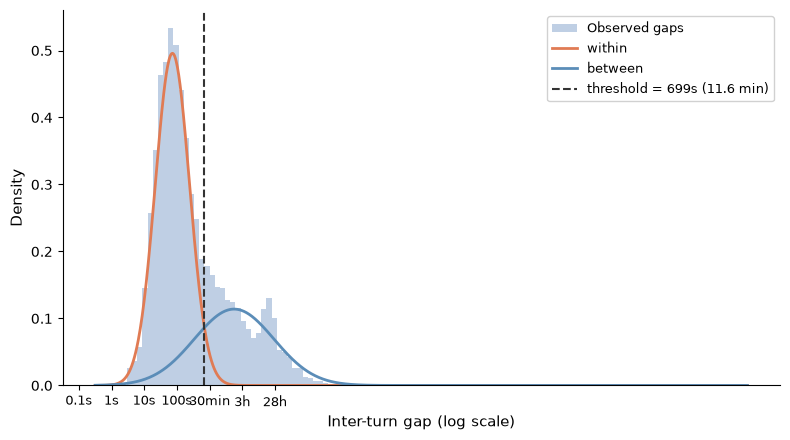

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.optimize import brentq

import warnings
warnings.filterwarnings("ignore")



def compute_gaps(df, max_samples=50_000):
    """Compute inter-turn gaps per user.
    Returns a sampled numpy array of gap values in seconds."""
    df = df.sort_values(["user_id", "time"])
    all_gaps = []
    for _, grp in df.groupby("user_id", sort=False):
        ts = grp["time"].values.astype("datetime64[s]").astype(np.int64)
        diffs = np.diff(ts).astype(float)
        all_gaps.append(diffs[diffs > 0])
    all_gaps = np.concatenate(all_gaps)
    if len(all_gaps) > max_samples:
        rng = np.random.default_rng(42)
        all_gaps = rng.choice(all_gaps, size=max_samples, replace=False)
    return all_gaps


def fit_gmm(gaps_seconds):
    log_gaps = np.log10(gaps_seconds)
    gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42, n_init=3)
    gmm.fit(log_gaps.reshape(-1, 1))

    order   = np.argsort(gmm.means_.flatten())
    means   = gmm.means_.flatten()[order]
    stds    = np.sqrt(gmm.covariances_.flatten())[order]
    weights = gmm.weights_[order]

    def diff_pdf(x):
        return weights[0] * norm.pdf(x, means[0], stds[0]) - weights[1] * norm.pdf(x, means[1], stds[1])

    try:
        log_thr = brentq(diff_pdf, means[0], means[1])
    except ValueError:
        log_thr = (means[0] + means[1]) / 2

    return log_gaps, log_thr, 10 ** log_thr, means, stds, weights


def plot_gmm(log_gaps, log_thr, means, stds, weights, threshold_s):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(log_gaps, bins=120, density=True, color="#b0c4de", edgecolor="none", alpha=0.8, label="Observed gaps")

    x = np.linspace(log_gaps.min() - 0.5, log_gaps.max() + 0.5, 1000)
    for m, s, w, c, lbl in zip(means, stds, weights,
                                ["#e07b54", "#5b8db8"],
                                ["within", "between"]):
        ax.plot(x, w * norm.pdf(x, m, s), color=c, lw=2.0, label=lbl)

    ax.axvline(log_thr, color="#333", lw=1.5, linestyle="--",
               label=f"threshold = {threshold_s:.0f}s ({threshold_s/60:.1f} min)")

    ax.set_xticks([-1, 0, 1, 2, 3, 4, 5])
    ax.set_xticklabels(["0.1s", "1s", "10s", "100s", "30min", "3h", "28h"], fontsize=9)
    ax.set_xlabel("Inter-turn gap (log scale)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    #ax.set_title("GMM-based Conversation Boundary Detection", fontsize=12)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

df_gemini["time"] = pd.to_datetime(df_gemini["time"].astype(str), utc=True, errors="coerce")

gaps = compute_gaps(df_gemini)
log_gaps, log_thr, threshold_s, means, stds, weights  = fit_gmm(gaps)

print(f"Threshold: {threshold_s:.1f}s ({threshold_s/60:.2f} min)")
plot_gmm(log_gaps, log_thr, means, stds, weights, threshold_s)